In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [2]:
import os

TRAIN_DIR = "../dataset/train"
TEST_DIR = "../dataset/test"

print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

print("\nTrain classes:")
print(os.listdir(TRAIN_DIR))

print("\nTest classes:")
print(os.listdir(TEST_DIR))

Train path: ../dataset/train
Test path: ../dataset/test

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
from collections import Counter

train_counts = {
    emotion: len(os.listdir(os.path.join(TRAIN_DIR, emotion)))
    for emotion in os.listdir(TRAIN_DIR)
}

test_counts = {
    emotion: len(os.listdir(os.path.join(TEST_DIR, emotion)))
    for emotion in os.listdir(TEST_DIR)
}

print("TRAIN DATA")
for emotion, count in train_counts.items():
    print(f"{emotion:10s}: {count}")

print("\nTEST DATA")
for emotion, count in test_counts.items():
    print(f"{emotion:10s}: {count}")

TRAIN DATA
angry     : 3995
disgust   : 436
fear      : 4097
happy     : 7215
neutral   : 4965
sad       : 4830
surprise  : 3171

TEST DATA
angry     : 958
disgust   : 111
fear      : 1024
happy     : 1774
neutral   : 1233
sad       : 1247
surprise  : 831


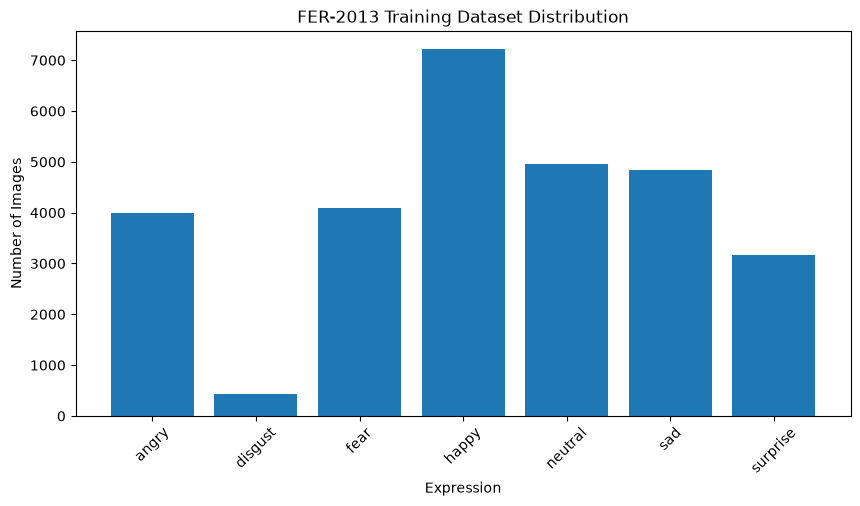

In [4]:
plt.figure(figsize=(10, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("FER-2013 Training Dataset Distribution")
plt.xlabel("Expression")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

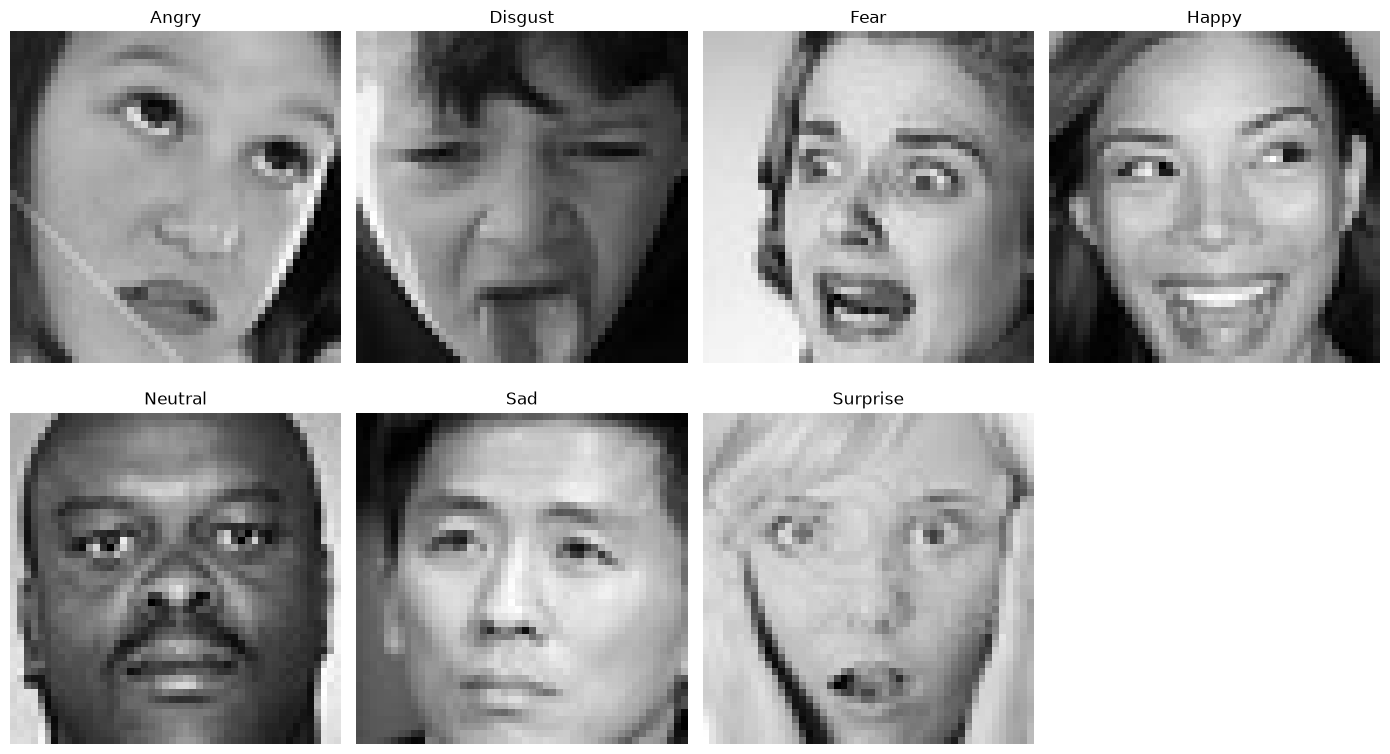

In [5]:
import random
from PIL import Image

classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(14, 8))

for i, emotion in enumerate(classes):
    emotion_path = os.path.join(TRAIN_DIR, emotion)
    image_name = random.choice(os.listdir(emotion_path))
    image_path = os.path.join(emotion_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


In [7]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (64, 48, 48, 1)
Label shape: (64, 7)


In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([
    
    # Data augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  input_shape=(48, 48, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    # 7 expressions
    layers.Dense(7, activation="softmax")
])

C:\Users\devds\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
import os
import tensorflow as tf

os.makedirs("../models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "../models/best_facial_expression_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30


C:\Users\devds\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.2795 - loss: 1.9872
Epoch 1: val_accuracy improved from None to 0.30329, saving model to ../models/best_facial_expression_model.keras

Epoch 1: finished saving model to ../models/best_facial_expression_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 151s 321ms/step - accuracy: 0.2795 - loss: 1.9872 - val_accuracy: 0.3033 - val_loss: 1.9190 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3978 - loss: 1.5535
Epoch 2: val_accuracy improved from 0.30329 to 0.44051, saving model to ../models/best_facial_expression_model.keras

Epoch 2: finished saving model to ../models/best_facial_expression_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 137s 304ms/step - accuracy: 0.3978 - loss: 1.5535 - val_accuracy: 0.4405 - val_loss: 1.4344 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.4546 - loss: 1.4121
Epoch 3: val_accuracy improved from 0.44051 to 0.47283, saving mod

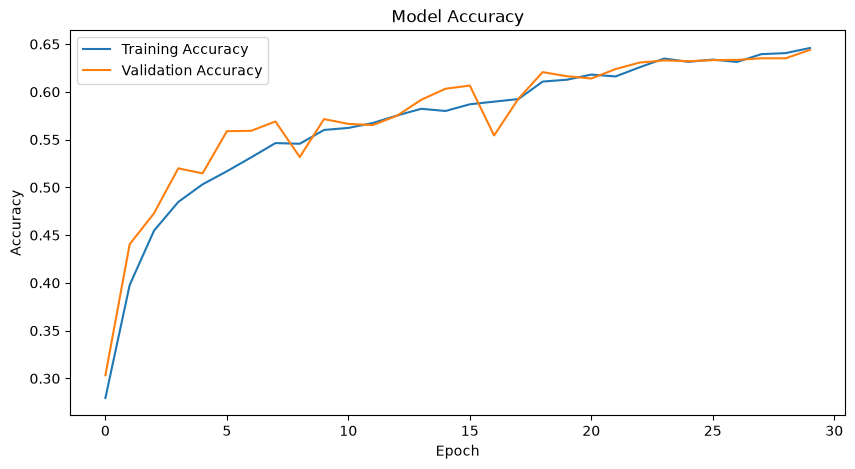

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

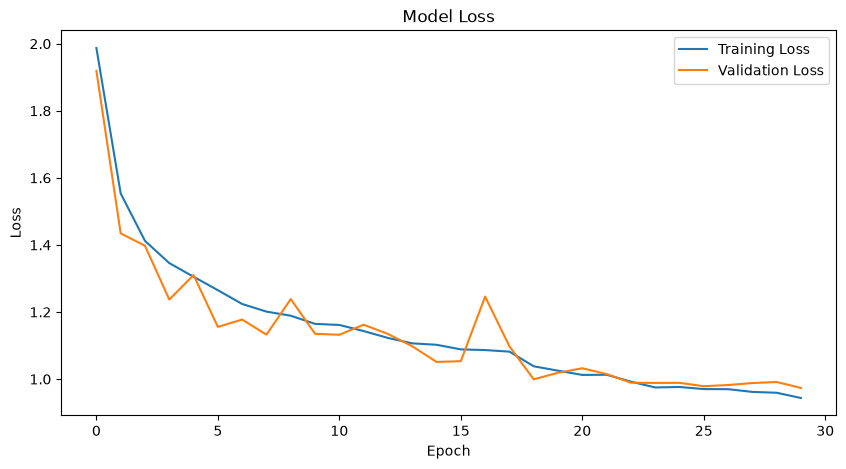

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
print(os.path.exists("../models/best_facial_expression_model.keras"))

True


In [21]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "../models/best_facial_expression_model.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [22]:
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.6439 - loss: 0.9736

Test Loss: 0.9736
Test Accuracy: 64.39%


In [23]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!


In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.5617    0.5846    0.5729       958
     disgust     0.7174    0.2973    0.4204       111
        fear     0.5584    0.3408    0.4233      1024
       happy     0.8704    0.8478    0.8589      1774
     neutral     0.5254    0.7137    0.6052      1233
         sad     0.5166    0.5108    0.5137      1247
    surprise     0.7540    0.7930    0.7730       831

    accuracy                         0.6439      7178
   macro avg     0.6434    0.5840    0.5954      7178
weighted avg     0.6481    0.6439    0.6383      7178



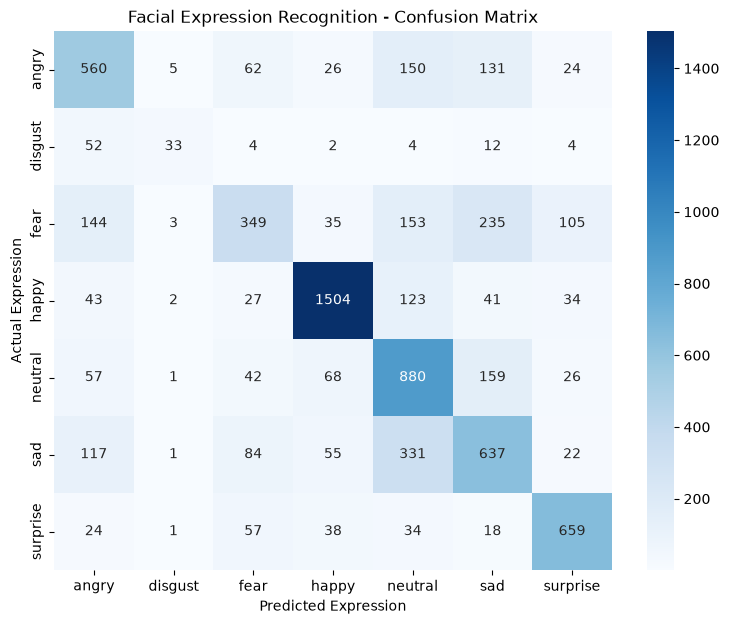

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Facial Expression Recognition - Confusion Matrix")
plt.xlabel("Predicted Expression")
plt.ylabel("Actual Expression")

plt.show()

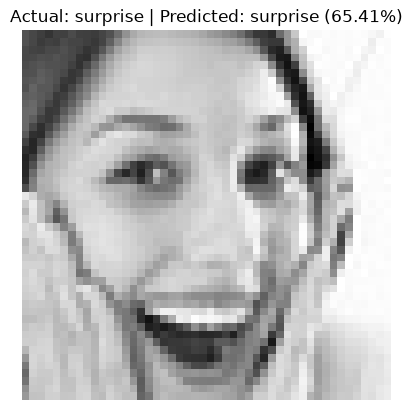

In [26]:
import random
import os
from PIL import Image

emotion = random.choice(class_names)

image_folder = os.path.join(TRAIN_DIR, emotion)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

image = Image.open(image_path).convert("L")
image = image.resize((48, 48))

image_array = np.array(image, dtype=np.float32) / 255.0
image_array = np.expand_dims(image_array, axis=(0, -1))

prediction = best_model.predict(image_array, verbose=0)[0]

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(image, cmap="gray")
plt.title(
    f"Actual: {emotion} | "
    f"Predicted: {predicted_class} ({confidence:.2f}%)"
)
plt.axis("off")
plt.show()